In [1]:
import torch
import torchvision
import torch.nn as nn
import os, numpy as np, matplotlib.pyplot as plt, pandas as pd, cv2, random
from PIL import Image
from model import BrainTumorModel
from utils import CLAHETransform, PretrainingDataset, SegmentationDataset, DiceLoss, calculate_dice, calculate_iou

# Pretraining the model on classification and reconstructing

In [2]:
batch_size = 48
backbone_name = 'convnext_nano.in12k_ft_in1k'

In [3]:
# Keep geometric and photometric parts separate to preserve spatial alignment
geom_transform = torchvision.transforms.Compose([
    torchvision.transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),
    torchvision.transforms.RandomRotation(degrees=15),
    torchvision.transforms.RandomHorizontalFlip(p=0.5),
])

photo_transform = torchvision.transforms.Compose([
    torchvision.transforms.ColorJitter(brightness=0.08, contrast=0.08),
    torchvision.transforms.RandomApply([CLAHETransform()], p=0.5),
])

base_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# 3. Instantiate the Pretraining Dataset & Loader
pretrain_dataset = PretrainingDataset(
    root=os.path.join('Data', 'classification', 'Training'),
    geom_transform=geom_transform,
    photo_transform=photo_transform,
    base_transform=base_transform
)

pretrain_loader = torch.utils.data.DataLoader(
    pretrain_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    num_workers=4, 
    pin_memory=True
)

In [4]:
test_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize(size = (224, 224)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
testing_dataset = torchvision.datasets.ImageFolder(root=os.path.join('Data', 'classification', 'Testing'), transform=test_transform)
testing_loader = torch.utils.data.DataLoader(testing_dataset, batch_size=batch_size, shuffle=True)

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Initialize the model
model = BrainTumorModel(backbone_name = backbone_name, num_classes=4, out_channels=1)
model.to(device)

# 2. Define the loss criteria
criterion_cls = nn.CrossEntropyLoss()
criterion_recon = nn.L1Loss()

base_lr = 5e-4
optimizer = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=0.05)
scaler = torch.amp.GradScaler()

num_epochs = 30
log_interval = 10
warmup_ratio = 0.05  # proportion of total steps used for linear warmup

# compute total steps (batches) to build the schedule
total_steps = num_epochs * len(pretrain_loader)
warmup_steps = max(1, int(total_steps * warmup_ratio))

warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor=0.1,
    end_factor=1.0,
    total_iters=warmup_steps
)
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=max(1, total_steps - warmup_steps),
    eta_min=5e-7
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[warmup_steps]
)

history = {
    'epoch': [],
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

global_step = 0

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    # 3. Modify loader unpacking to receive augmented images, clean target images, and labels
    for batch_idx, (augmented_images, clean_images, labels) in enumerate(pretrain_loader, 1):
        augmented_images = augmented_images.to(device)
        clean_images = clean_images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        with torch.amp.autocast(device_type='cuda' if device.type == 'cuda' else 'cpu'):
            # Forward pass: extract classification and reconstruction outputs
            cls_output, reconstruction_output = model(augmented_images)
            
            # Calculate classification and reconstruction losses
            cls_loss = criterion_cls(cls_output, labels)
            reconstruction_loss = criterion_recon(torch.mean(reconstruction_output, dim = 1), torch.mean(clean_images, dim = 1))
            
            loss = cls_loss + 50.0 * reconstruction_loss
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # step scheduler per batch (after optimizer.step)
        scheduler.step()
        global_step += 1

        train_loss += loss.item() * augmented_images.size(0)
        
        # Calculate training accuracy metrics on classification predictions
        _, preds = torch.max(cls_output, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        if batch_idx % log_interval == 0 or batch_idx == len(pretrain_loader):
            batch_loss = train_loss / train_total
            batch_acc = train_correct / train_total
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch + 1}/{num_epochs} | Batch {batch_idx}/{len(pretrain_loader)} | "
                    f"Train Loss: {batch_loss:.4f} | Train Acc: {batch_acc:.4f} | LR: {current_lr:.6e}")

    epoch_loss = train_loss / train_total
    epoch_acc = train_correct / train_total

    # 4. Validation Loop
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in testing_loader:
            images = images.to(device)
            labels = labels.to(device)
            with torch.amp.autocast(device_type='cuda' if device.type == 'cuda' else 'cpu'):
                # Unpack the classification outputs and discard the reconstruction output during validation
                cls_outputs, _ = model(images)
                loss = criterion_cls(cls_outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(cls_outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss / val_total
    val_acc = val_correct / val_total

    history['epoch'].append(epoch + 1)
    history['train_loss'].append(epoch_loss)
    history['train_acc'].append(epoch_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch + 1}/{num_epochs} completed | "
            f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

history_df = pd.DataFrame(history)
print('\nTraining history:')
print(history_df)

/home/thoal/anaconda3/envs/pytorch/lib/python3.13/site-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 1/30 | Batch 10/119 | Train Loss: 61.1740 | Train Acc: 0.3521 | LR: 7.528090e-05
Epoch 1/30 | Batch 20/119 | Train Loss: 55.9161 | Train Acc: 0.4844 | LR: 1.005618e-04
Epoch 1/30 | Batch 30/119 | Train Loss: 49.9620 | Train Acc: 0.5403 | LR: 1.258427e-04
Epoch 1/30 | Batch 40/119 | Train Loss: 44.8958 | Train Acc: 0.5724 | LR: 1.511236e-04
Epoch 1/30 | Batch 50/119 | Train Loss: 40.4769 | Train Acc: 0.5921 | LR: 1.764045e-04
Epoch 1/30 | Batch 60/119 | Train Loss: 36.6530 | Train Acc: 0.6132 | LR: 2.016854e-04
Epoch 1/30 | Batch 70/119 | Train Loss: 33.4446 | Train Acc: 0.6250 | LR: 2.269663e-04
Epoch 1/30 | Batch 80/119 | Train Loss: 30.6991 | Train Acc: 0.6341 | LR: 2.522472e-04
Epoch 1/30 | Batch 90/119 | Train Loss: 28.5804 | Train Acc: 0.6477 | LR: 2.775281e-04
Epoch 1/30 | Batch 100/119 | Train Loss: 26.7355 | Train Acc: 0.6590 | LR: 3.028090e-04
Epoch 1/30 | Batch 110/119 | Train Loss: 25.2014 | Train Acc: 0.6619 | LR: 3.280899e-04
Epoch 1/30 | Batch 119/119 | Train Loss: 

/home/thoal/anaconda3/envs/pytorch/lib/python3.13/site-packages/torch/optim/lr_scheduler.py:209: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 2/30 | Batch 60/119 | Train Loss: 8.2447 | Train Acc: 0.8420 | LR: 4.999999e-04
Epoch 2/30 | Batch 70/119 | Train Loss: 8.0925 | Train Acc: 0.8452 | LR: 4.999870e-04
Epoch 2/30 | Batch 80/119 | Train Loss: 8.0084 | Train Acc: 0.8497 | LR: 4.999528e-04
Epoch 2/30 | Batch 90/119 | Train Loss: 7.9405 | Train Acc: 0.8525 | LR: 4.998971e-04
Epoch 2/30 | Batch 100/119 | Train Loss: 7.8351 | Train Acc: 0.8529 | LR: 4.998200e-04
Epoch 2/30 | Batch 110/119 | Train Loss: 7.6960 | Train Acc: 0.8597 | LR: 4.997214e-04
Epoch 2/30 | Batch 119/119 | Train Loss: 7.5634 | Train Acc: 0.8654 | LR: 4.996145e-04
Epoch 2/30 completed | Train Loss: 7.5634 | Train Acc: 0.8654 | Val Loss: 0.2092 | Val Acc: 0.9199
Epoch 3/30 | Batch 10/119 | Train Loss: 6.1658 | Train Acc: 0.9187 | LR: 4.994753e-04
Epoch 3/30 | Batch 20/119 | Train Loss: 6.0621 | Train Acc: 0.9260 | LR: 4.993148e-04
Epoch 3/30 | Batch 30/119 | Train Loss: 6.1510 | Train Acc: 0.9132 | LR: 4.991328e-04
Epoch 3/30 | Batch 40/119 | Train Loss

In [6]:
torch.save(model.state_dict(), os.path.join('Data', 'Models', f'brain_tumor_pretrain_model_{backbone_name.split('.')[0]}.pth'))

In [7]:
model = BrainTumorModel(backbone_name = backbone_name, num_classes=4, out_channels=1)
state_dict = torch.load(os.path.join('Data', 'Models', f'brain_tumor_pretrain_model_{backbone_name.split('.')[0]}.pth'))
model.load_state_dict(state_dict)
model.to('cuda')

BrainTumorModel(
  (backbone): FeatureListNet(
    (stem_0): Conv2d(3, 40, kernel_size=(4, 4), stride=(4, 4))
    (stem_1): LayerNorm2d((40,), eps=1e-06, elementwise_affine=True)
    (stages_0): ConvNeXtStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): ConvNeXtBlock(
          (conv_dw): Conv2d(40, 40, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=40)
          (norm): LayerNorm2d((40,), eps=1e-06, elementwise_affine=True)
          (mlp): GlobalResponseNormMlp(
            (fc1): Conv2d(40, 160, kernel_size=(1, 1), stride=(1, 1))
            (act): GELU()
            (drop1): Dropout(p=0.0, inplace=False)
            (grn): GlobalResponseNorm()
            (fc2): Conv2d(160, 40, kernel_size=(1, 1), stride=(1, 1))
            (drop2): Dropout(p=0.0, inplace=False)
          )
          (shortcut): Identity()
          (drop_path): Identity()
        )
        (1): ConvNeXtBlock(
          (conv_dw): Conv2d(40, 40, kernel_size=(7, 7), stride=(1, 

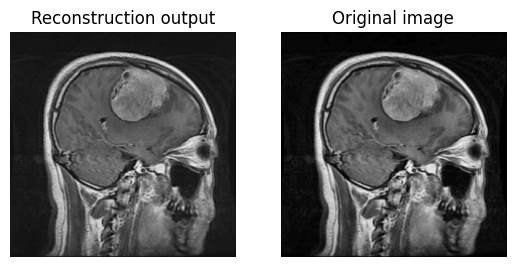

In [8]:
images, labels = next(iter(testing_loader))
images = images[0]
images = images.to('cuda')

labels = labels[0]

cls_out, recon_out = model(images.unsqueeze(0))

plt.subplot(1, 2, 1)
plt.imshow(recon_out.squeeze(0).permute(1, 2, 0).detach().cpu(), cmap = 'gray')
plt.title('Reconstruction output')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(images.mean(dim = 0).detach().cpu(), cmap = 'gray')
plt.title('Original image')
plt.axis('off')
plt.show()

# Segmentation Finetuning

In [5]:
segmentation_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToPILImage(),
    torchvision.transforms.ColorJitter(brightness=0.08, contrast=0.08),
    torchvision.transforms.RandomApply([CLAHETransform()], p=0.5),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToPILImage(),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [6]:
train_segmentation_dataset = SegmentationDataset(transform = segmentation_transform)
test_segmentation_dataset = SegmentationDataset(transform = test_transform, train = False)

train_segmentation_dataloader = torch.utils.data.DataLoader(
    train_segmentation_dataset, 
    batch_size = batch_size, 
    shuffle = False, 
    num_workers = 4,
    pin_memory = True
)

test_segmentation_dataloader = torch.utils.data.DataLoader(
    test_segmentation_dataset, 
    batch_size = batch_size, 
    shuffle = False, 
    num_workers = 4,
    pin_memory = True
)

image, mask, class_id = test_segmentation_dataset[92]

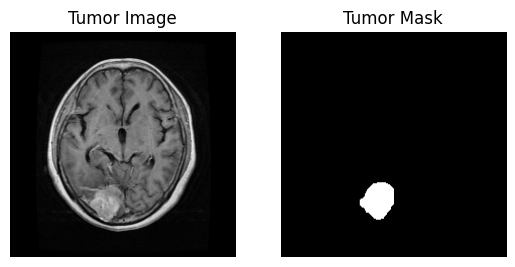

In [7]:
plt.subplot(1, 2, 1)
plt.imshow(image.mean(dim = 0), cmap = 'gray')
plt.title('Tumor Image')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(mask.permute(1, 2, 0), cmap = 'gray')
plt.title('Tumor Mask')
plt.axis('off')
plt.show()

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Initialize the model
model = BrainTumorModel(backbone_name = backbone_name, num_classes=4, out_channels=1)
state_dict = torch.load(os.path.join('Data', 'Models', f'brain_tumor_pretrain_model_{backbone_name.split('.')[0]}.pth'))
model.load_state_dict(state_dict)
model.to('cuda')

# 2. Define the loss criteria
criterion_cls = nn.CrossEntropyLoss()
criterion_segmentation = DiceLoss()

base_lr = 5e-4
optimizer = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=0.05)
scaler = torch.amp.GradScaler()

num_epochs = 30
log_interval = 10
warmup_ratio = 0.05  # proportion of total steps used for linear warmup

# compute total steps (batches) to build the schedule
total_steps = num_epochs * len(pretrain_loader)
warmup_steps = max(1, int(total_steps * warmup_ratio))

warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor=0.1,
    end_factor=1.0,
    total_iters=warmup_steps
)
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=max(1, total_steps - warmup_steps),
    eta_min=5e-7
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[warmup_steps]
)

history = {
    'epoch': [],
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

global_step = 0

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_idx, (images, masks, labels) in enumerate(train_segmentation_dataloader, 1):
        images = images.to(device)
        masks = masks.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        with torch.amp.autocast(device_type='cuda' if device.type == 'cuda' else 'cpu'):
            # Forward pass: extract classification and reconstruction outputs
            cls_output, segmentation_output = model(images)
            
            # Calculate classification and segmentation losses
            cls_loss = criterion_cls(cls_output, labels)
            segmentation_loss = criterion_segmentation(segmentation_output, masks)
            
            loss = cls_loss + 5.0 * segmentation_loss
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # step scheduler per batch (after optimizer.step)
        scheduler.step()
        global_step += 1

        train_loss += loss.item() * images.size(0)
        
        # Calculate training accuracy metrics on classification predictions
        _, preds = torch.max(cls_output, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        if batch_idx % log_interval == 0 or batch_idx == len(train_segmentation_dataloader):
            batch_loss = train_loss / train_total
            batch_acc = train_correct / train_total
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch + 1}/{num_epochs} | Batch {batch_idx}/{len(train_segmentation_dataloader)} | "
                    f"Train Loss: {batch_loss:.4f} | Train Acc: {batch_acc:.4f} | LR: {current_lr:.6e}")

    epoch_loss = train_loss / train_total
    epoch_acc = train_correct / train_total

    # 4. Validation Loop
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, masks, labels in test_segmentation_dataloader:
            images = images.to(device)
            masks = masks.to(device)
            labels = labels.to(device)
            with torch.amp.autocast(device_type='cuda' if device.type == 'cuda' else 'cpu'):
                # Unpack the classification outputs and discard the reconstruction output during validation
                cls_outputs, segmentation_output = model(images)
                cls_loss = criterion_cls(cls_outputs, labels)
                segmentation_loss = criterion_segmentation(segmentation_output, masks) 
                
            val_loss += (cls_loss.item() + segmentation_loss.item()) * images.size(0)
            _, preds = torch.max(cls_outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss / val_total
    val_acc = val_correct / val_total

    history['epoch'].append(epoch + 1)
    history['train_loss'].append(epoch_loss)
    history['train_acc'].append(epoch_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch + 1}/{num_epochs} completed | "
            f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

history_df = pd.DataFrame(history)
print('\nTraining history:')
print(history_df)

/home/thoal/anaconda3/envs/pytorch/lib/python3.13/site-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 1/30 | Batch 10/56 | Train Loss: 7.4956 | Train Acc: 0.6896 | LR: 7.528090e-05
Epoch 1/30 | Batch 20/56 | Train Loss: 6.5398 | Train Acc: 0.7042 | LR: 1.005618e-04
Epoch 1/30 | Batch 30/56 | Train Loss: 6.1154 | Train Acc: 0.7340 | LR: 1.258427e-04
Epoch 1/30 | Batch 40/56 | Train Loss: 5.8913 | Train Acc: 0.7630 | LR: 1.511236e-04
Epoch 1/30 | Batch 50/56 | Train Loss: 5.7486 | Train Acc: 0.7804 | LR: 1.764045e-04
Epoch 1/30 | Batch 56/56 | Train Loss: 5.6878 | Train Acc: 0.7887 | LR: 1.915730e-04
Epoch 1/30 completed | Train Loss: 5.6878 | Train Acc: 0.7887 | Val Loss: 1.2994 | Val Acc: 0.8355
Epoch 2/30 | Batch 10/56 | Train Loss: 5.1238 | Train Acc: 0.8229 | LR: 2.168539e-04
Epoch 2/30 | Batch 20/56 | Train Loss: 5.0278 | Train Acc: 0.8615 | LR: 2.421348e-04
Epoch 2/30 | Batch 30/56 | Train Loss: 4.9835 | Train Acc: 0.8764 | LR: 2.674157e-04
Epoch 2/30 | Batch 40/56 | Train Loss: 4.9161 | Train Acc: 0.8807 | LR: 2.926966e-04
Epoch 2/30 | Batch 50/56 | Train Loss: 4.8365 | Tra

/home/thoal/anaconda3/envs/pytorch/lib/python3.13/site-packages/torch/optim/lr_scheduler.py:209: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 4/30 | Batch 10/56 | Train Loss: 2.4008 | Train Acc: 0.8646 | LR: 5.000000e-04
Epoch 4/30 | Batch 20/56 | Train Loss: 2.2280 | Train Acc: 0.8948 | LR: 4.999893e-04
Epoch 4/30 | Batch 30/56 | Train Loss: 2.2037 | Train Acc: 0.8931 | LR: 4.999572e-04
Epoch 4/30 | Batch 40/56 | Train Loss: 2.1318 | Train Acc: 0.8953 | LR: 4.999036e-04
Epoch 4/30 | Batch 50/56 | Train Loss: 2.0882 | Train Acc: 0.8908 | LR: 4.998286e-04
Epoch 4/30 | Batch 56/56 | Train Loss: 2.0609 | Train Acc: 0.8921 | LR: 4.997734e-04
Epoch 4/30 completed | Train Loss: 2.0609 | Train Acc: 0.8921 | Val Loss: 0.5876 | Val Acc: 0.9094
Epoch 5/30 | Batch 10/56 | Train Loss: 1.8545 | Train Acc: 0.8771 | LR: 4.996642e-04
Epoch 5/30 | Batch 20/56 | Train Loss: 1.8160 | Train Acc: 0.8979 | LR: 4.995335e-04
Epoch 5/30 | Batch 30/56 | Train Loss: 1.8061 | Train Acc: 0.9076 | LR: 4.993815e-04
Epoch 5/30 | Batch 40/56 | Train Loss: 1.7822 | Train Acc: 0.9083 | LR: 4.992082e-04
Epoch 5/30 | Batch 50/56 | Train Loss: 1.7262 | Tra

In [9]:
torch.save(model.state_dict(), os.path.join('Data', 'Models', f'brain_tumor_segmentation_model_{backbone_name.split('.')[0]}.pth'))

In [10]:
state_dict = torch.load(os.path.join('Data', 'Models', f'brain_tumor_segmentation_model_{backbone_name.split('.')[0]}.pth'))
model = BrainTumorModel(backbone_name = backbone_name, num_classes = 4, out_channels = 1)
model.load_state_dict(state_dict)
model.to('cuda')

BrainTumorModel(
  (backbone): FeatureListNet(
    (stem_0): Conv2d(3, 40, kernel_size=(4, 4), stride=(4, 4))
    (stem_1): LayerNorm2d((40,), eps=1e-06, elementwise_affine=True)
    (stages_0): ConvNeXtStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): ConvNeXtBlock(
          (conv_dw): Conv2d(40, 40, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=40)
          (norm): LayerNorm2d((40,), eps=1e-06, elementwise_affine=True)
          (mlp): GlobalResponseNormMlp(
            (fc1): Conv2d(40, 160, kernel_size=(1, 1), stride=(1, 1))
            (act): GELU()
            (drop1): Dropout(p=0.0, inplace=False)
            (grn): GlobalResponseNorm()
            (fc2): Conv2d(160, 40, kernel_size=(1, 1), stride=(1, 1))
            (drop2): Dropout(p=0.0, inplace=False)
          )
          (shortcut): Identity()
          (drop_path): Identity()
        )
        (1): ConvNeXtBlock(
          (conv_dw): Conv2d(40, 40, kernel_size=(7, 7), stride=(1, 

In [11]:
images, masks, labels = next(iter(test_segmentation_dataloader))
images = images.to('cuda')
masks = masks.to('cuda')
labels = labels.to('cuda')

index = 12

In [12]:
images = images[index].to('cuda')
masks = masks[index].to('cuda')
labels = labels[index].to('cuda')

In [13]:
cls_out, seg_out = model(images.unsqueeze(0))

In [14]:
seg_out = seg_out.squeeze(0)
seg_out = (torch.sigmoid(seg_out) > 0.5).to(torch.float32)

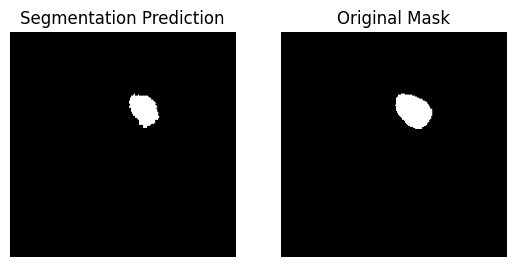

In [15]:
plt.subplot(1, 2, 1)
plt.imshow(seg_out.permute(1, 2, 0).detach().cpu(), cmap = 'gray')
plt.axis('off')
plt.title('Segmentation Prediction')

plt.subplot(1, 2, 2)
plt.imshow(masks.permute(1, 2, 0).detach().cpu(), cmap = 'gray')
plt.axis('off')
plt.title('Original Mask')
plt.show()

In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.eval()
val_iou_total = 0.0
val_dice_total = 0.0
val_total = 0.0
with torch.no_grad():
        for images, masks, labels in test_segmentation_dataloader:
            images = images.to(device)
            masks = masks.to(device)
            labels = labels.to(device)
            
            with torch.amp.autocast(device_type='cuda' if device.type == 'cuda' else 'cpu'):
                cls_outputs, segmentation_output = model(images)

            # Accumulate Segmentation Metrics (using your functions)
            # Assuming you also added the calculate_dice function
            val_iou_total += calculate_iou(segmentation_output, masks) * images.size(0)
            val_dice_total += calculate_dice(segmentation_output, masks) * images.size(0)
            val_total += labels.size(0)

val_iou = val_iou_total / val_total
val_dice = val_dice_total / val_total
            

In [17]:
val_iou

0.789377506458665

In [18]:
val_dice

0.8444820986888654